In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pickle
import json
import os

In [ ]:
df = pd.read_csv('churn.csv')
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])

print("Data loaded and irrelevant columns removed.")
display(df.head())

Data loaded and irrelevant columns removed.


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [ ]:
categorical_features = ['Geography', 'Gender']
numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary', 'NumOfProducts'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])
scaled_features = preprocessor.fit_transform(df)

print("Data prepared for clustering.")
print(f"Shape of prepared data: {scaled_features.shape}")

Data prepared for clustering.
Shape of prepared data: (10000, 11)


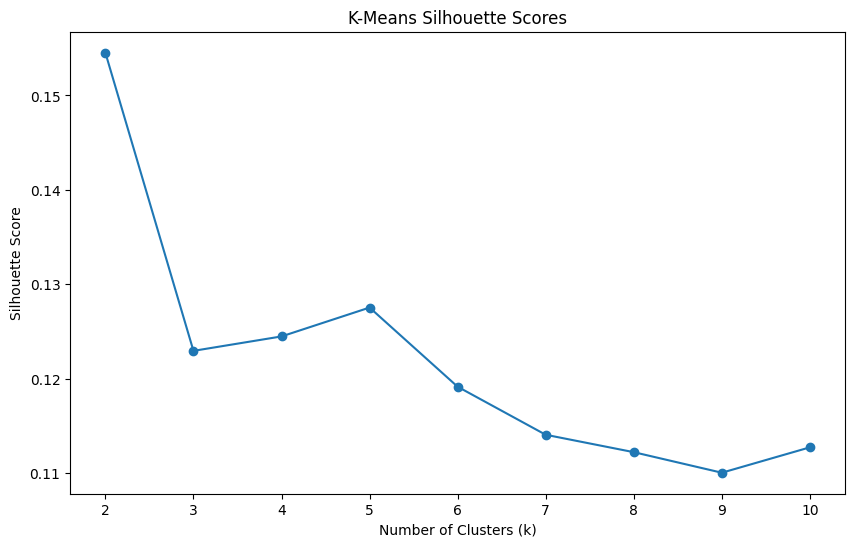

Best number of clusters (k) based on Silhouette Score: 2


In [ ]:
k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans_model.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('K-Means Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.savefig('silhouette_scores.png')
plt.show()

best_k_idx = np.argmax(silhouette_scores)
best_k = k_range[best_k_idx]

print(f"Best number of clusters (k) based on Silhouette Score: {best_k}")

In [ ]:
final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_model.fit_predict(scaled_features)

df['Cluster'] = cluster_labels

print(f"Customers assigned to {best_k} clusters.")
display(df.head())

Customers assigned to 2 clusters.


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Cluster
0,619,France,Female,42,2,0.00,1,1,1,101348.88,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,1
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,1


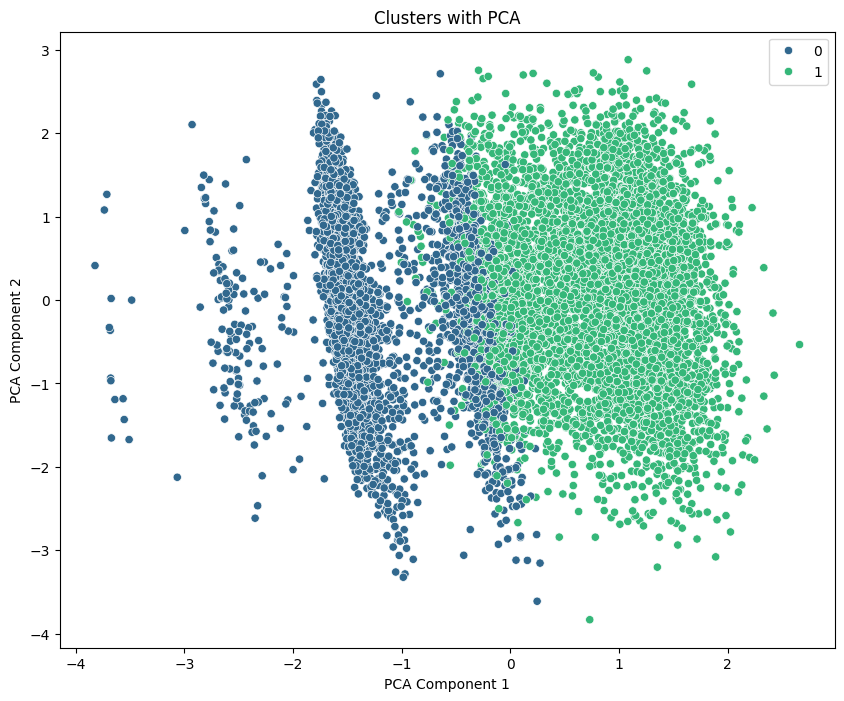

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


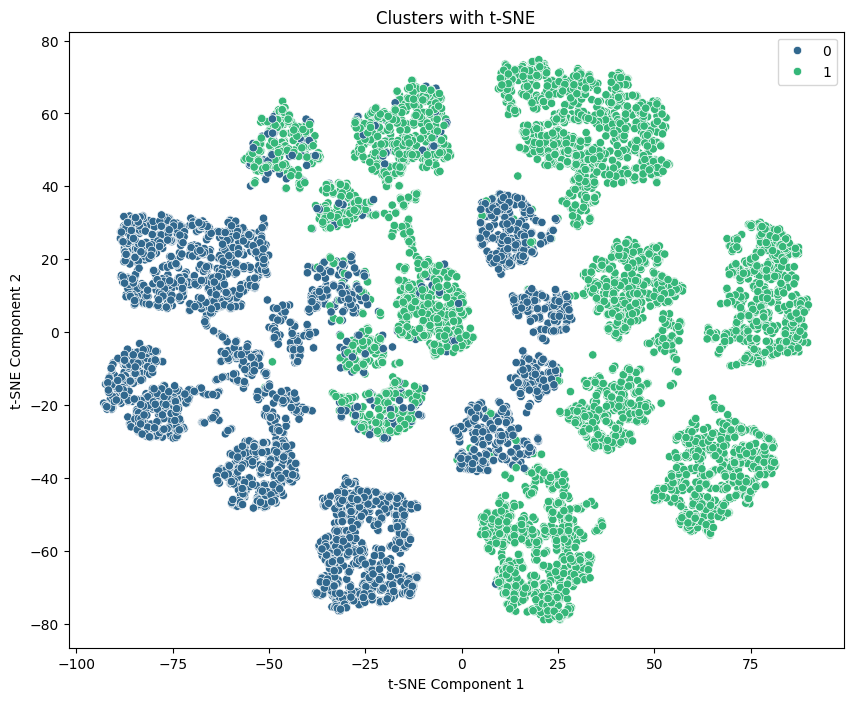

Cluster visualizations generated.


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=pca_components[:, 0], y=pca_components[:, 1], hue=cluster_labels, palette='viridis', legend='full'
)
plt.title('Clusters with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.savefig('pca_clusters.png')
plt.show()

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate='auto')
tsne_components = tsne.fit_transform(scaled_features)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_components[:, 0], y=tsne_components[:, 1], hue=cluster_labels, palette='viridis', legend='full'
)
plt.title('Clusters with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.savefig('tsne_clusters.png')
plt.show()

print("Cluster visualizations generated.")

In [ ]:
cluster_profiles = []

for i in range(best_k):
    cluster_df = df[df['Cluster'] == i]
    num_profile = {col: {
        'mean': round(cluster_df[col].mean(), 2),
        'median': round(cluster_df[col].median(), 2)}
        for col in numerical_features}

    cat_profile = {col: cluster_df[col].mode()[0] for col in categorical_features}

    label = ""
    if num_profile['Balance']['mean'] < df['Balance'].mean() / 2:
        label += "Low-Balance "
    elif num_profile['Balance']['mean'] > df['Balance'].mean() * 1.5:
        label += "High-Balance "
    else:
        label += "Average-Balance "

    label += f"{cat_profile['Geography']} {cat_profile['Gender']} Customers"

    profile = {
        'cluster_id': int(i),
        'size': len(cluster_df),
        'percentage': round(len(cluster_df) / len(df) * 100, 2),
        'numerical_features': num_profile,
        'categorical_features': cat_profile,
        'label': label
    }
    cluster_profiles.append(profile)

    print(f"\n--- Cluster {i} ({label}) ---")
    print(f"Size: {len(cluster_df)} ({profile['percentage']}%) ")
    print("Numerical:", num_profile)
    print("Categorical:", cat_profile)

print("Cluster profiles generated.")

In [ ]:
with open('preprocessing_transformer.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print("Preprocessing transformer saved to 'preprocessing_transformer.pkl'")

with open('clustering_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Clustering model saved to 'clustering_model.pkl'")

def convert_to_native(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(elem) for elem in obj]
    return obj

segmentation_metrics = {
    'algorithm': 'KMeans',
    'best_k': best_k,
    'silhouette_score': round(silhouette_score(scaled_features, cluster_labels), 3)
}

with open('segmentation_metrics.json', 'w') as f:
    json.dump(convert_to_native(segmentation_metrics), f, indent=4)
print("Segmentation metrics saved to 'segmentation_metrics.json'")

with open('cluster_profiles.json', 'w') as f:
    json.dump(convert_to_native(cluster_profiles), f, indent=4)
print("Cluster profiles saved to 'cluster_profiles.json'")

print("All results saved successfully.")